# Product case 2: Banking system
## Description of the tasks completed
- Provided with 3 datasets (client data with credit amount and last payment date, dictionary with credit type names and coefficients of reserves), I calculated total reserves based on the number of days passed from specific date, wrote a function for auto computation in similar datasets.
- Utilized __matplotlib.pyplot__ library
- Manipulated with data formats, splitted values in the rows
- Focused mainly on reserves calculations, since the data was overall clean

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import datetime

In [204]:
df = pd.read_csv('Client_Data_01082022.csv', sep=';')
bucket_coeff = pd.read_csv('bucket_coeff.csv', sep=';')
credit_type = pd.read_csv('credit_type.csv', sep=';')

In [206]:
df.head()

,id_credit,last_inst_payment,amt_instalment,id_credit_type
0,237789,04.05.2022,25669,888
1,238348,18.02.2022,5271,246
2,238164,06.05.2022,33732,246
3,237613,14.03.2022,6108,246
4,237745,05.02.2022,4917,888


In [208]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1474 entries, 0 to 1473
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id_credit          1474 non-null   int64 
 1   last_inst_payment  1474 non-null   object
 2   amt_instalment     1474 non-null   int64 
 3   id_credit_type     1474 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 46.2+ KB


In [210]:
# typecasting to date
df['last_inst_payment'] = pd.to_datetime(df['last_inst_payment'], format= '%d.%m.%Y')

In [212]:
df.head()

,id_credit,last_inst_payment,amt_instalment,id_credit_type
0,237789,2022-05-04,25669,888
1,238348,2022-02-18,5271,246
2,238164,2022-05-06,33732,246
3,237613,2022-03-14,6108,246
4,237745,2022-02-05,4917,888


In [214]:
bucket_coeff.head()

,id_bucket,range_bucket,coeff,valid_to
0,1,0-15,"0,05",01.01.3000
1,2,16-30,"0,25",01.01.3000
2,3,31-60,"0,33",01.01.3000
3,4,61-90,"0,6",01.01.3000
4,5,91-120,"0,75",01.01.3000


In [216]:
credit_type.head()

,id_credit_type,name_credit_type
0,117,POS-special
1,118,POS-classic
2,119,POS-restruct
3,245,RC-experiment
4,246,RC


## Task 1: Calculating the total volume of reserves as of August 1, 2022.

In [219]:
# identifying the number of days passed from the last payment to August 1
df['days_passed'] = pd.to_datetime('2022-08-01', format='%Y-%m-%d') - df['last_inst_payment']

In [221]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1474 entries, 0 to 1473
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype          
---  ------             --------------  -----          
 0   id_credit          1474 non-null   int64          
 1   last_inst_payment  1474 non-null   datetime64[ns] 
 2   amt_instalment     1474 non-null   int64          
 3   id_credit_type     1474 non-null   int64          
 4   days_passed        1474 non-null   timedelta64[ns]
dtypes: datetime64[ns](1), int64(3), timedelta64[ns](1)
memory usage: 57.7 KB


In [223]:
# converting to int to compare with ranges
df['days_passed'] = df['days_passed'].dt.days.astype('int')

In [225]:
df.tail()

,id_credit,last_inst_payment,amt_instalment,id_credit_type,days_passed
1469,238698,2022-06-04,6238,246,58
1470,238938,2022-03-29,28495,247,125
1471,238378,2022-03-04,9045,1028,150
1472,238794,2022-04-03,8809,246,120
1473,238076,2022-03-10,26314,119,144


In [227]:
bucket_coeff.tail()

,id_bucket,range_bucket,coeff,valid_to
3,4,61-90,"0,6",01.01.3000
4,5,91-120,"0,75",01.01.3000
5,6,121-150,"0,87",01.01.3000
6,7,151-180,"0,94",01.01.3000
7,8,181+,1,01.01.3000


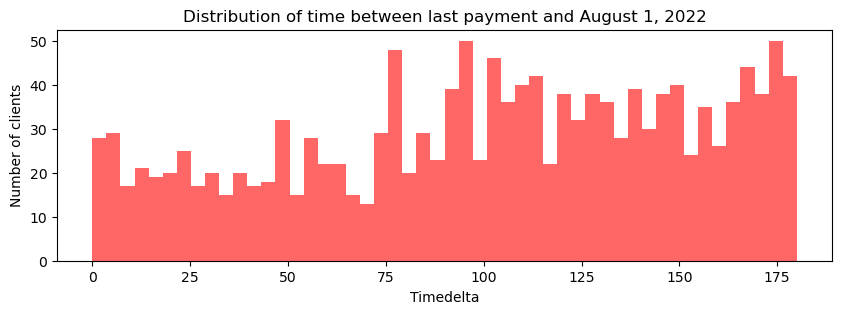

The greatest value in the column: 180


In [229]:
plt.figure(figsize=(10,3))
plt.hist(df['days_passed'], bins = 50, alpha = 0.6, color='r')
plt.title('Distribution of time between last payment and August 1, 2022')
plt.xlabel('Timedelta')
plt.ylabel('Number of clients')
plt.show()

print('The greatest value in the column:', df['days_passed'].max())

According to the greatest timedelta, the row "181+" can be replaced with "180-200" for example. So that it will be easier to split the column __"range_bucket"__ and then compare with "days_passed" to identify the coefficient.

In [231]:
bucket_coeff.loc[bucket_coeff['range_bucket']== '181+', 'range_bucket'] = '181-200'

In [233]:
bucket_coeff[['left_border', 'right_border']] = bucket_coeff['range_bucket'].str.split('-', n=1, expand=True).astype(int)

And now I can calculate the coefficient based on the condition: __left_border <= days_passed <= right_border__

In [236]:
# cross join
df['key'] = 1
bucket_coeff['key'] = 1
merged = df.merge(bucket_coeff, on='key')

# filtering appropriate range
df = merged[(merged['days_passed'] >= merged['left_border']) & (merged['days_passed'] <= merged['right_border'])]

In [238]:
df.head()

,id_credit,last_inst_payment,amt_instalment,id_credit_type,days_passed,key,id_bucket,range_bucket,coeff,valid_to,left_border,right_border
3,237789,2022-05-04,25669,888,89,1,4,61-90,"0,6",01.01.3000,61,90
14,238348,2022-02-18,5271,246,164,1,7,151-180,"0,94",01.01.3000,151,180
19,238164,2022-05-06,33732,246,87,1,4,61-90,"0,6",01.01.3000,61,90
29,237613,2022-03-14,6108,246,140,1,6,121-150,"0,87",01.01.3000,121,150
38,237745,2022-02-05,4917,888,177,1,7,151-180,"0,94",01.01.3000,151,180


In [240]:
# Dropping unnecessary columns
df = df.drop(columns=['key', 'id_bucket', 'left_border', 'right_border', 'range_bucket', 'valid_to'])

In [242]:
df['coeff'] = df['coeff'].str.replace(',', '.')
df['coeff'] = df['coeff'].astype(float)
df['reserve'] = df['amt_instalment'] * df['coeff']

In [244]:
df.head()

,id_credit,last_inst_payment,amt_instalment,id_credit_type,days_passed,coeff,reserve
3,237789,2022-05-04,25669,888,89,0.60,15401.40
14,238348,2022-02-18,5271,246,164,0.94,4954.74
19,238164,2022-05-06,33732,246,87,0.60,20239.20
29,237613,2022-03-14,6108,246,140,0.87,5313.96
38,237745,2022-02-05,4917,888,177,0.94,4621.98


In [246]:
total = round(df['reserve'].sum(), 2)
print('The total volume of reserves as of August 1, 2022:', total)

The total volume of reserves as of August 1, 2022: 16844393.74


## Task 2: Writing a function that will take as input a reporting date (for example, August 1, 2022) and a dataframe and will calculate the total volume of bank reserves on the reporting date.

In [250]:
def calculate_reserves(df, credit_amount_column, last_payment_date_column, date):
    """
    Provide the reporting date as yyyy-mm-dd, e.g. '2022-08-01'
    Return: a dataframe with new column "reserve" with calculated reserve amount and a total volume of bank reserves
    """
    bins = [0, 15, 30, 60, 90, 120, 150, 180, float('inf')]
    coeff = [0.05, 0.25, 0.33, 0.6, 0.75, 0.87, 0.94, 1]

    df['days_passed'] = pd.to_datetime(date, format='%Y-%m-%d') - df[last_payment_date_column]

    df['days_passed'] = df['days_passed'].dt.days.astype('int')

    df['reserve'] = df[credit_amount_column] * pd.cut(df['days_passed'], bins = bins, labels = coeff, include_lowest = True).astype('float')

    total = round(df['reserve'].sum(), 2)

    return (df, total)

## Task 3: assuming that starting from August 1, no one has paid their loans. Plotting a graph of total reserves for a set of reporting dates from August 1 to August 30 and estimating the absolute and percentage increase in reserves for the month.

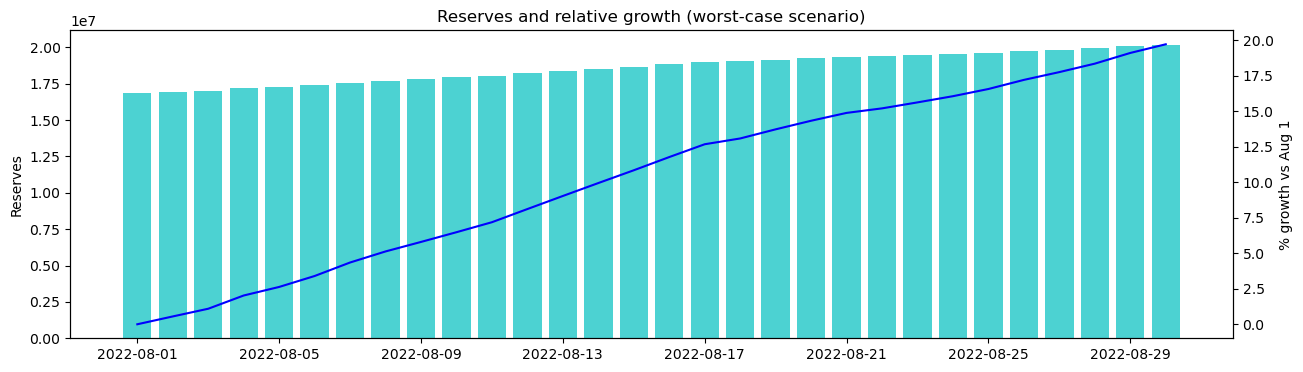

Value on August 1: 16844393.74
Value on August 30: 20163024.49


In [292]:
dates = []
total_reserves = []
for i in range(1, 31):
    date = f'2022-08-{i}'
    df_new, total = calculate_reserves(df, 'amt_instalment', 'last_inst_payment', date)
    dates.append(pd.to_datetime(date, format='%Y-%m-%d'))
    total_reserves.append(total)

base = total_reserves[0]

growth_perc = [(x - base) / base * 100 for x in total_reserves]

fig, ax1 = plt.subplots(figsize=(15,4))
ax1.bar(dates, total_reserves, color = 'c', alpha=0.7)
ax1.set_ylabel('Reserves')

ax2 = ax1.twinx()
ax2.plot(dates, growth_perc, color='b')
ax2.set_ylabel('% growth vs Aug 1')

plt.title('Reserves and relative growth (worst-case scenario)')
plt.show()
print('Value on August 1:', total_reserves[0])
print('Value on August 30:', total_reserves[-1])

## Task 4: Building visualizations that will help to track the size of reserves (e.g. by credit type).

In [300]:
df.head()
df = df.merge(credit_type, on = 'id_credit_type', how='inner')

In [302]:
credit_types_reserves = df.groupby('name_credit_type')['reserve'].sum().reset_index()
credit_types_reserves.head()

,name_credit_type,reserve
0,Autocredit-bail,243248.77
1,Autocredit-classic,2378191.95
2,Autocredit-new,154342.57
3,Autocredit-restruct,903255.77
4,Autocredit-select,677270.73


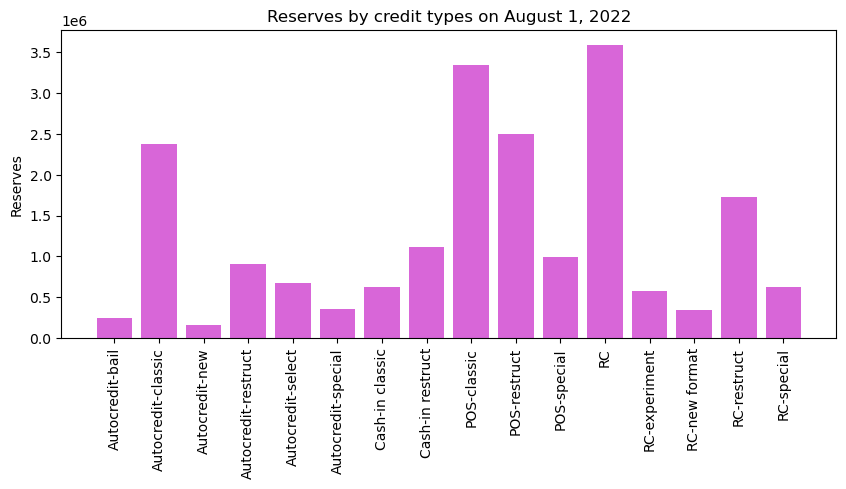

In [312]:
plt.figure(figsize=(10,4))
plt.bar(credit_types_reserves['name_credit_type'], credit_types_reserves['reserve'], color = 'm', alpha=0.6)
plt.xticks(rotation=90)
plt.title('Reserves by credit types on August 1, 2022')
plt.ylabel('Reserves')
plt.show()